<a href="https://colab.research.google.com/github/saskiaalifah/SaskiaAlifah_2411531002_ML2526/blob/main/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

Load dan Split Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/ML/Dataset/advertising.csv"
df = pd.read_csv(DATA_PATH)

X = df.drop("Sales", axis = 1)
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)


Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Visualisasikan data

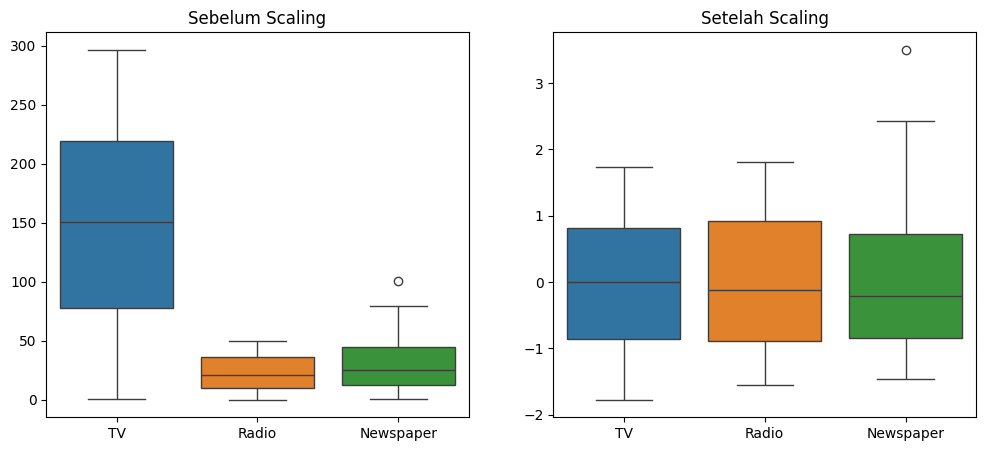

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (12,5))
sns.boxplot(data = X_train[['TV','Radio','Newspaper']], ax = ax[0])
ax[0].set_title("Sebelum Scaling")

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = X_train.columns)
sns.boxplot(data = X_train_scaled_df[['TV','Radio','Newspaper']], ax = ax[1])
ax[1].set_title("Setelah Scaling")
plt.show()

Pelatihan model tanpa Regularization

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_test_lr = lr.predict(X_test_scaled)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

print("Linear Regression")
print("RMSE Train :", rmse_train_lr)
print("RMSE Test :", rmse_test_lr)
print("Coefficients :", lr.coef_)

Linear Regression
RMSE Train : 1.6358920055378559
RMSE Test : 1.7052146229349234
Coefficients : [4.58720774 1.48984025 0.08791597]


Pelatihan model dengan L2 Regularization (Ridge Regression)


In [ ]:
ridge = Ridge(alpha = 1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

print("\nRidge Regression (alpha = 1.0)")
print("RMSE Train :", rmse_train_ridge)
print("RMSE Test :", rmse_test_ridge)
print("Coefficients :", ridge.coef_)


Ridge Regression (alpha = 1.0)
RMSE Train : 1.6361615871481856
RMSE Test : 1.7074302367919385
Coefficients : [4.55913661 1.48074139 0.0914114 ]


Pelatihan model dengan L1 Regularization (Lasso Regression)


In [ ]:
lasso = Lasso(alpha = 0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_train_lasso = lasso.predict(X_train_scaled)
y_pred_test_lasso = lasso.predict(X_test_scaled)

rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))

print("\nLasso Regression (alpha = 0.1)")
print("RMSE Train :", rmse_train_lasso)
print("RMSE Test :", rmse_test_lasso)
print("Coefficients :", lasso.coef_)


Lasso Regression (alpha = 0.1)
RMSE Train : 1.643031487122971
RMSE Test : 1.7117675228539946
Coefficients : [4.49218143 1.42301597 0.01566227]


Pelatihan model dengan L1 & L2 Regularization menggunakan beberapa nilai Lambda

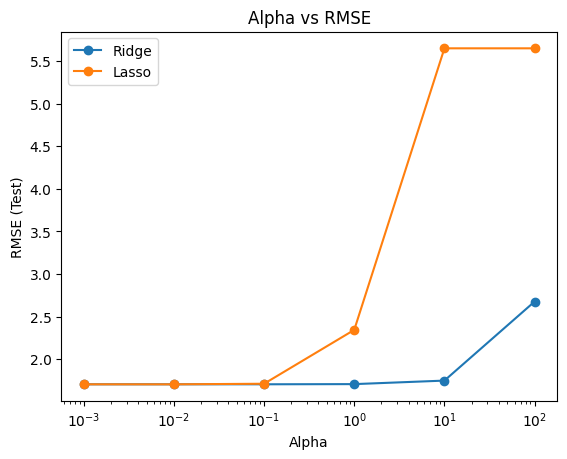

In [ ]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_rmse = []
lasso_rmse = []

for a in alphas:
  r = Ridge(alpha = a).fit(X_train_scaled, y_train)
  l = Lasso(alpha = a).fit(X_train_scaled, y_train)

  ridge_rmse.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
  lasso_rmse.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

plt.plot(alphas, ridge_rmse, marker = 'o', label = "Ridge")
plt.plot(alphas, lasso_rmse, marker = 'o', label = "Lasso")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt.legend()
plt.title("Alpha vs RMSE")
plt.show()

# Tugas Praktikum

**Pengujian dengan 5 nilai lambda lain**

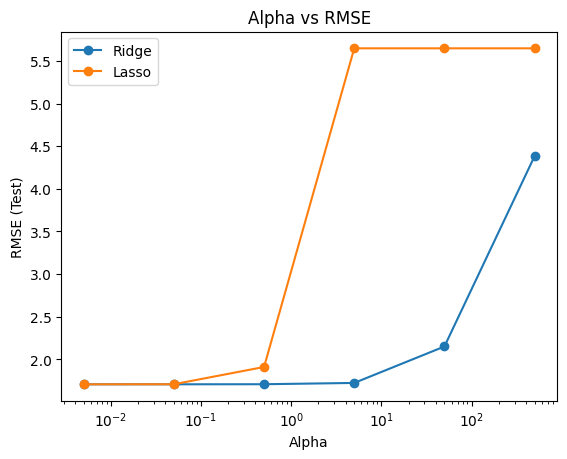

In [ ]:
# nilai lambda / alpha selain nilai pada latihan
alphas = [0.005, 0.05, 0.5, 5, 50, 500]

ridge_rmse = []
lasso_rmse = []

for a in alphas:
  r = Ridge(alpha = a).fit(X_train_scaled, y_train)
  l = Lasso(alpha = a).fit(X_train_scaled, y_train)

  ridge_rmse.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
  lasso_rmse.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

plt.plot(alphas, ridge_rmse, marker = 'o', label = "Ridge")
plt.plot(alphas, lasso_rmse, marker = 'o', label = "Lasso")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt.legend()
plt.title("Alpha vs RMSE")
plt.show()

Grafik Perbandingan  RMSE Train dan RMSE Test

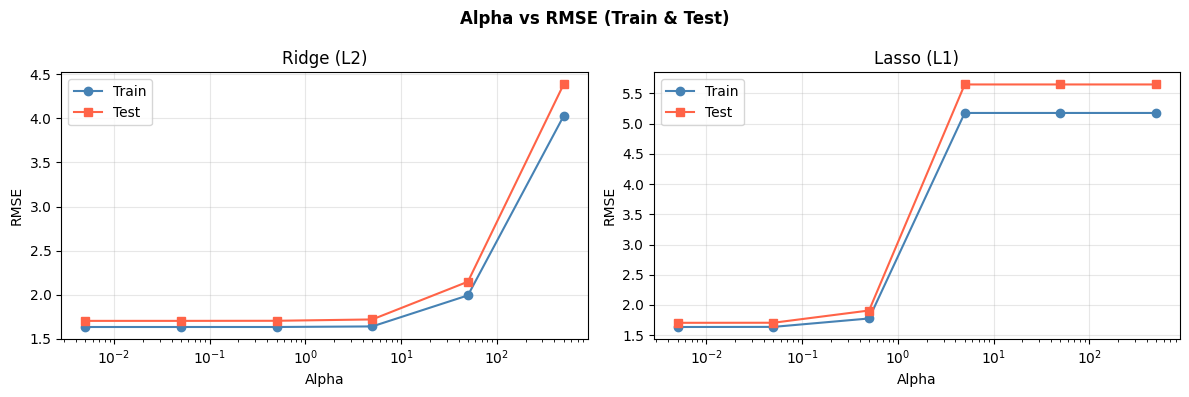

In [ ]:
ridge_rmse_train = []
lasso_rmse_train = []
ridge_rmse_test  = []
lasso_rmse_test  = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    ridge_rmse_train.append(np.sqrt(mean_squared_error(y_train, r.predict(X_train_scaled))))
    lasso_rmse_train.append(np.sqrt(mean_squared_error(y_train, l.predict(X_train_scaled))))
    ridge_rmse_test.append( np.sqrt(mean_squared_error(y_test,  r.predict(X_test_scaled))))
    lasso_rmse_test.append( np.sqrt(mean_squared_error(y_test,  l.predict(X_test_scaled))))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, train_r, test_r in zip(
    axes,
    ['Ridge (L2)', 'Lasso (L1)'],
    [ridge_rmse_train, lasso_rmse_train],
    [ridge_rmse_test,  lasso_rmse_test]
):
    ax.plot(alphas, train_r, marker='o', label='Train', color='steelblue')
    ax.plot(alphas, test_r,  marker='s', label='Test',  color='tomato')
    ax.set_xscale('log')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('RMSE')
    ax.set_title(name)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Alpha vs RMSE (Train & Test)', fontweight='bold')
plt.tight_layout()
plt.show()

**Grafik perubahan koefisien terhadap alpha/lambda**

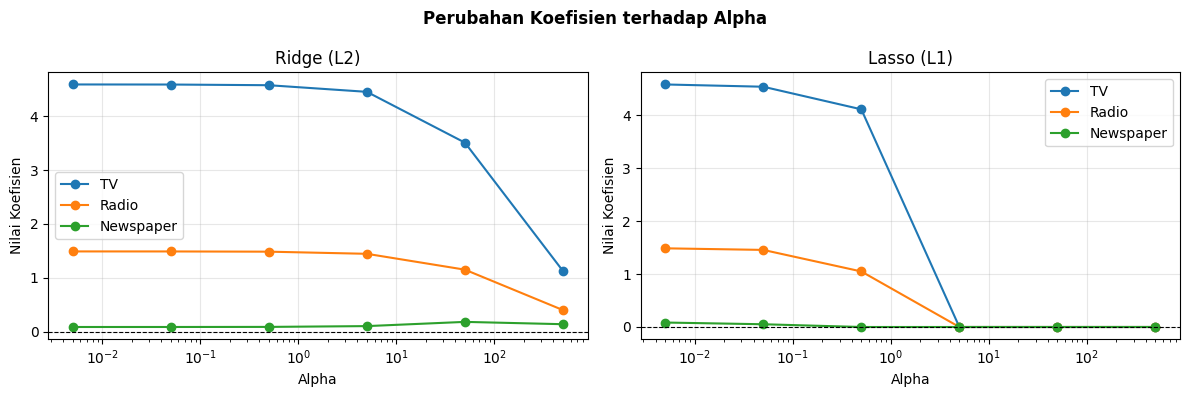

In [ ]:
feature_names = list(X.columns)  # ['TV', 'Radio', 'Newspaper']

ridge_coefs = []
lasso_coefs = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)
    ridge_coefs.append(r.coef_)
    lasso_coefs.append(l.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, coefs in zip(axes, ['Ridge (L2)', 'Lasso (L1)'], [ridge_coefs, lasso_coefs]):
    for i, feat in enumerate(feature_names):
        ax.plot(alphas, coefs[:, i], marker='o', label=feat)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xscale('log')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('Nilai Koefisien')
    ax.set_title(name)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Perubahan Koefisien terhadap Alpha', fontweight='bold')
plt.tight_layout()
plt.show()